T1w shape: (300, 320, 208), T2w shape: (300, 320, 208)
Using coronal slice y=133
T1 slice shape: (300, 208), range: [0.00, 357.00]
T2 slice shape: (300, 208), range: [0.00, 304.00]


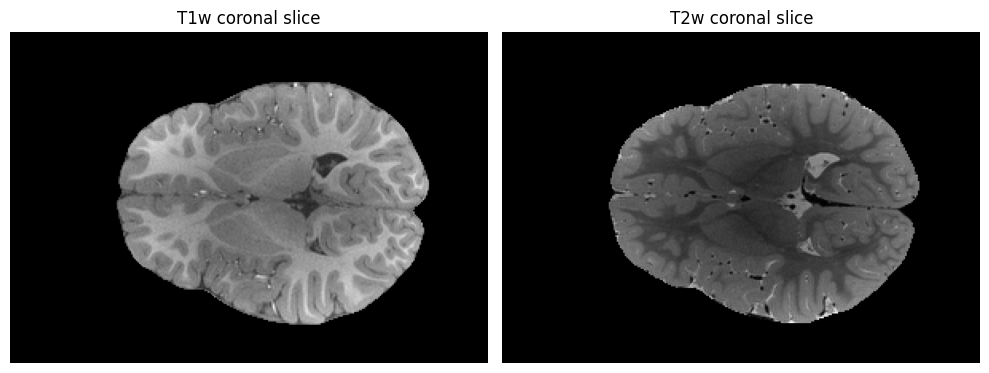

In [1]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import mutual_info_score
from scipy.ndimage import affine_transform
import SimpleITK as sitk

%matplotlib inline

DATA_DIR = '.'
t1_img = nib.load(os.path.join(DATA_DIR, 'T1w.nii'))
t2_img = nib.load(os.path.join(DATA_DIR, 'T2w.nii'))
t1_data = t1_img.get_fdata().astype(np.float64)
t2_data = t2_img.get_fdata().astype(np.float64)
y_idx = int(t1_data.shape[1] // 2.4)
t1_slice = t1_data[:, y_idx, :].copy()
t2_slice = t2_data[:, y_idx, :].copy()

print(f'T1w shape: {t1_data.shape}, T2w shape: {t2_data.shape}')
print(f'Using coronal slice y={y_idx}')
print(f'T1 slice shape: {t1_slice.shape}, range: [{t1_slice.min():.2f}, {t1_slice.max():.2f}]')
print(f'T2 slice shape: {t2_slice.shape}, range: [{t2_slice.min():.2f}, {t2_slice.max():.2f}]')

def normalize(img):
    vmin, vmax = img.min(), img.max()
    return (img - vmin) / (vmax - vmin + 1e-10)

t1_norm = normalize(t1_slice)
t2_norm = normalize(t2_slice)

# Display
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(t1_slice.T, cmap='gray', origin='lower')
axes[0].set_title('T1w coronal slice'); axes[0].axis('off')
axes[1].imshow(t2_slice.T, cmap='gray', origin='lower')
axes[1].set_title('T2w coronal slice'); axes[1].axis('off')
plt.tight_layout(); plt.show()

Mask pixels: 22441 / 62400 (36.0%)
SIMILARITY METRICS — T1w vs T2w (coronal slice)
Metric   Manual          Library        
----------------------------------------
SSD      219007989.0000  N/A            
RIU      0.450659        N/A            
CC       0.054420        0.054420       
MI       0.946282        0.655315       

Metric   T1w vs T1w (identity)
------------------------------
SSD      0.0000              
RIU      1.000000            
CC       1.000000            
MI       6.953628            


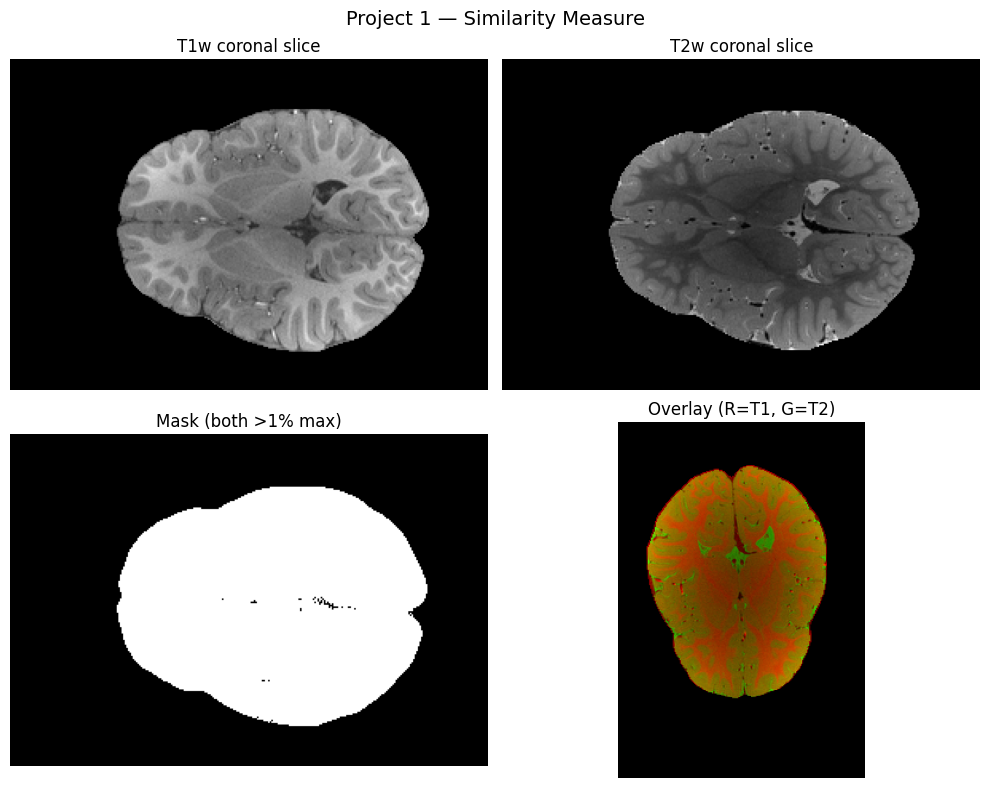

In [2]:
# ============================================================
# 1. Mask generation (threshold-based)
# ============================================================
t1_thresh = t1_slice.max() * 0.02
t2_thresh = t2_slice.max() * 0.02
mask = (t1_slice > t1_thresh) & (t2_slice > t2_thresh)
print(f'Mask pixels: {mask.sum()} / {mask.size} ({100*mask.sum()/mask.size:.1f}%)')

# ============================================================
# 2. Similarity metrics (manual implementation)
# ============================================================
def masked_flat(a, m):
    return a[m].flatten()

def ssd(a, b, mask):
    """Sum of Squared Differences (lower = more similar)."""
    va, vb = masked_flat(a, mask), masked_flat(b, mask)
    return np.sum((va - vb) ** 2)

def riu(a, b, mask):
    """Ratio Image Uniformity (higher = more similar)."""
    va, vb = masked_flat(a, mask), masked_flat(b, mask)
    eps = 1e-10
    ratio = va / (vb + eps)
    return 1.0 - np.std(ratio) / (np.mean(np.abs(ratio)) + eps)

def cc(a, b, mask):
    """Pearson Correlation Coefficient (range [-1, 1], higher = more similar)."""
    va, vb = masked_flat(a, mask), masked_flat(b, mask)
    ma, mb = va.mean(), vb.mean()
    num = np.sum((va - ma) * (vb - mb))
    den = np.sqrt(np.sum((va - ma)**2) * np.sum((vb - mb)**2))
    return num / (den + 1e-10)

def mutual_information(a, b, mask, bins=256):
    """Mutual Information using histogram binning (higher = more similar)."""
    va, vb = masked_flat(a, mask), masked_flat(b, mask)
    def digitize(v, bins):
        vmin, vmax = v.min(), v.max()
        if vmax == vmin:
            return np.zeros_like(v, dtype=np.int32)
        return np.floor((v - vmin) / (vmax - vmin) * (bins - 1)).astype(np.int32)
    a_d = digitize(va, bins)
    b_d = digitize(vb, bins)
    joint = np.zeros((bins, bins), dtype=np.float64)
    for i in range(len(a_d)):
        joint[a_d[i], b_d[i]] += 1
    joint /= joint.sum()
    pa, pb = joint.sum(axis=1), joint.sum(axis=0)
    def entropy(p):
        p = p[p > 0]
        return -np.sum(p * np.log2(p))
    return entropy(pa) + entropy(pb) - entropy(joint.flatten())

# ============================================================
# 3. Standard library wrappers
# ============================================================
def cc_standard(a, b, mask):
    va, vb = masked_flat(a, mask), masked_flat(b, mask)
    r, _ = pearsonr(va, vb)
    return r

def mi_standard(a, b, mask, bins=256):
    va, vb = masked_flat(a, mask), masked_flat(b, mask)
    vmin_a, vmax_a = va.min(), va.max()
    vmin_b, vmax_b = vb.min(), vb.max()
    a_d = np.floor((va - vmin_a) / (vmax_a - vmin_a + 1e-10) * (bins - 1)).astype(int)
    b_d = np.floor((vb - vmin_b) / (vmax_b - vmin_b + 1e-10) * (bins - 1)).astype(int)
    return mutual_info_score(a_d, b_d)

# ============================================================
# 4. Compute and compare
# ============================================================
print('='*60)
print('SIMILARITY METRICS — T1w vs T2w (coronal slice)')
print('='*60)
print(f"{'Metric':<8} {'Manual':<15} {'Library':<15}")
print('-'*40)

ssd_val = ssd(t1_slice, t2_slice, mask)
print(f"{'SSD':<8} {ssd_val:<15.4f} {'N/A':<15}")

riu_val = riu(t1_slice, t2_slice, mask)
print(f"{'RIU':<8} {riu_val:<15.6f} {'N/A':<15}")

cc_man = cc(t1_slice, t2_slice, mask)
cc_lib = cc_standard(t1_slice, t2_slice, mask)
print(f"{'CC':<8} {cc_man:<15.6f} {cc_lib:<15.6f}")

mi_man = mutual_information(t1_norm, t2_norm, mask)
mi_lib = mi_standard(t1_norm, t2_norm, mask)
print(f"{'MI':<8} {mi_man:<15.6f} {mi_lib:<15.6f}")

# T1w vs itself (identity)
print(f"\n{'Metric':<8} {'T1w vs T1w (identity)':<20}")
print('-'*30)
mask_t1 = t1_slice > t1_slice.max() * 0.01
print(f"{'SSD':<8} {ssd(t1_slice, t1_slice, mask_t1):<20.4f}")
print(f"{'RIU':<8} {riu(t1_slice, t1_slice, mask_t1):<20.6f}")
print(f"{'CC':<8} {cc(t1_slice, t1_slice, mask_t1):<20.6f}")
print(f"{'MI':<8} {mutual_information(t1_slice, t1_slice, mask_t1):<20.6f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].imshow(t1_slice.T, cmap='gray', origin='lower')
axes[0, 0].set_title('T1w coronal slice'); axes[0, 0].axis('off')
axes[0, 1].imshow(t2_slice.T, cmap='gray', origin='lower')
axes[0, 1].set_title('T2w coronal slice'); axes[0, 1].axis('off')
axes[1, 0].imshow(mask.T, cmap='gray', origin='lower')
axes[1, 0].set_title(f'Mask (both >1% max)'); axes[1, 0].axis('off')
overlay = np.zeros((*t1_slice.shape, 3))
overlay[:, :, 0] = t1_norm
overlay[:, :, 1] = t2_norm
axes[1, 1].imshow(np.clip(overlay, 0, 1), origin='lower')
axes[1, 1].set_title('Overlay (R=T1, G=T2)'); axes[1, 1].axis('off')
plt.suptitle('Project 1 — Similarity Measure', fontsize=14)
plt.tight_layout(); plt.show()